# RLA studies with MINT

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt
from mint.MuC import MuDecaySimulator
from mint import plot_tools as pt

## Build PA and RLA lattices

Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x178010dc0>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x1780009a0>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])
[2.15768000e+03 2.15780349e+03 2.15792699e+03 ... 1.00000000e-03
 1.00000000e-03 1.00000000e-03]
Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x178010c30>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x1780022a0>
Setting additional beamdiv to 0.001
Setting additional beamsize to 0.01
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent', 'beamdiv', 'beamsize'])
[ 2157.68        2160.60501144  2163.53002288 ... 17587.56156373
 17590.48657517 17593.4115866 ]
Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x176fe7d40>
Setting additional tangent to <functi

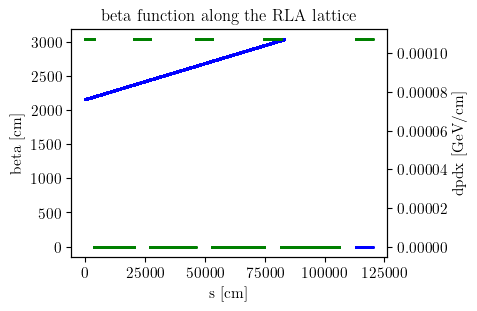

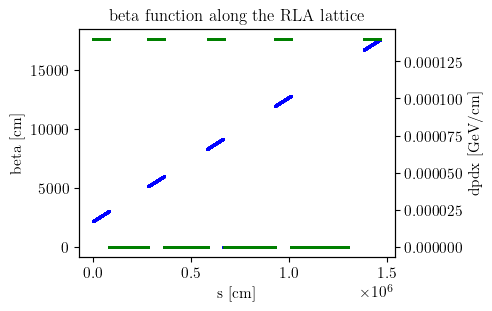

In [10]:
# PA (implemented in MINT as a straight lattice)
pa_lattice = lt.create_straight_lattice(
    name="PA",
    short_name="pa",
    total_length=160e2,
    n_elements=100_000,
    p0_injected=0.225,
    p0_ejected=1.25,
    beamdiv=1e-3,
    beamdiv_z=1e-2,
    beamsize=1.0,
    Nmu_per_bunch=2e12,
)

# RLA1
rla_lattice1 = lt.create_RLA_lattice(
    name="RLA1",
    short_name="rla1",
    straight_length=70e2,
    n_elements=100_000,
    p0_injection=1.25,
    dp_dx_LA=0.75/70e2,
    beamdiv_z=1e-2,
    beamdiv=1e-3,
    beamsize=1e-2,
    half=True,
    Nmu_per_bunch=2e12,
)

# RLA2
rla_lattice2 = lt.create_RLA_lattice(
    name="RLA2",
    short_name="rla2",
    straight_length=829e2,
    n_elements=100_000,
    p0_injection=5.0,
    dp_dx_LA=11.6 / 829e2,
    beamdiv_z=1e-2,
    beamdiv=1e-3,
    beamsize=1e-2,
    half=False,
    Nmu_per_bunch=2e12,
)

# Optional: PA + RLA combined machine
combined_lattice = lt.append_lattices(
    pa_lattice,
    rla_lattice2,
    vert_shift=0.0,
    hor_shift=20e2,
    RLA=False,
    p0_injection=0.225,
    Nmu_per_bunch_inj=2e12,
)

In [11]:
def _as_curve(values, u):

    arr = np.asarray(values)

    if arr.ndim == 0:

        return np.full_like(u, float(arr), dtype=float)

    if arr.shape == (1,):

        return np.full_like(u, float(arr[0]), dtype=float)

    return arr





def plot_lattice_geometry(lattice, title):

    x_long, y_hor, _ = lattice.vertices

    plt.figure(figsize=(7, 3))

    plt.plot(x_long / 100, y_hor / 100, lw=1.1)

    plt.xlabel("z [m]")

    plt.ylabel("x [m]")

    plt.title(title)

    plt.gca().set_aspect("equal", adjustable="box")

    plt.tight_layout()





def plot_beam_dynamics(lattice, title):

    u = np.linspace(0, 1, 3000)

    s_m = _as_curve(lattice.s(u), u) / 100



    beam_p0 = _as_curve(lattice.beam_p0(u), u)

    beamsize_x = _as_curve(lattice.beamsize_x(u), u)

    beamsize_y = _as_curve(lattice.beamsize_y(u), u)

    beamdiv_x = _as_curve(lattice.beamdiv_x(u), u)

    beamdiv_y = _as_curve(lattice.beamdiv_y(u), u)

    beamdiv_z = _as_curve(lattice.beamdiv_z(u), u)



    fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

    ax = ax.flatten()



    ax[0].plot(s_m, beam_p0, color="black")

    ax[0].set_ylabel("p0 [GeV]")



    ax[1].plot(s_m, beamsize_x, color="tab:blue", label="$\\sigma_x$")

    ax[1].plot(s_m, beamsize_y, color="tab:orange", label="$\\sigma_y$")

    ax[1].set_ylabel("beam size [cm]")

    ax[1].legend(frameon=False)



    ax[2].plot(s_m, beamdiv_x, color="tab:green", label="$\\sigma_{x'}$")

    ax[2].plot(s_m, beamdiv_y, color="tab:red", label="$\\sigma_{y'}$")

    ax[2].set_ylabel("transverse divergence [rad]")

    ax[2].set_xlabel("s [m]")

    ax[2].legend(frameon=False)



    ax[3].plot(s_m, beamdiv_z, color="tab:purple")

    ax[3].set_ylabel("longitudinal divergence [rad]")

    ax[3].set_xlabel("s [m]")



    fig.suptitle(title)

    fig.tight_layout()

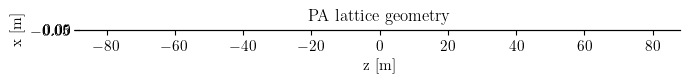

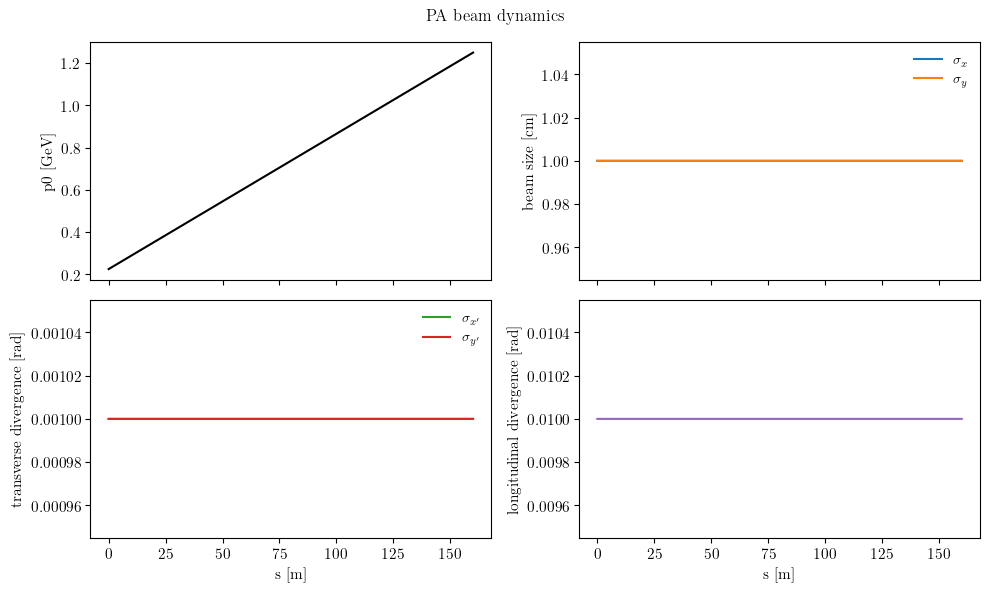

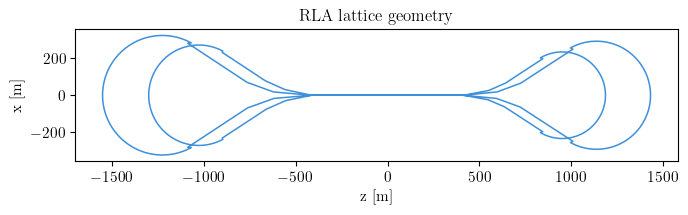

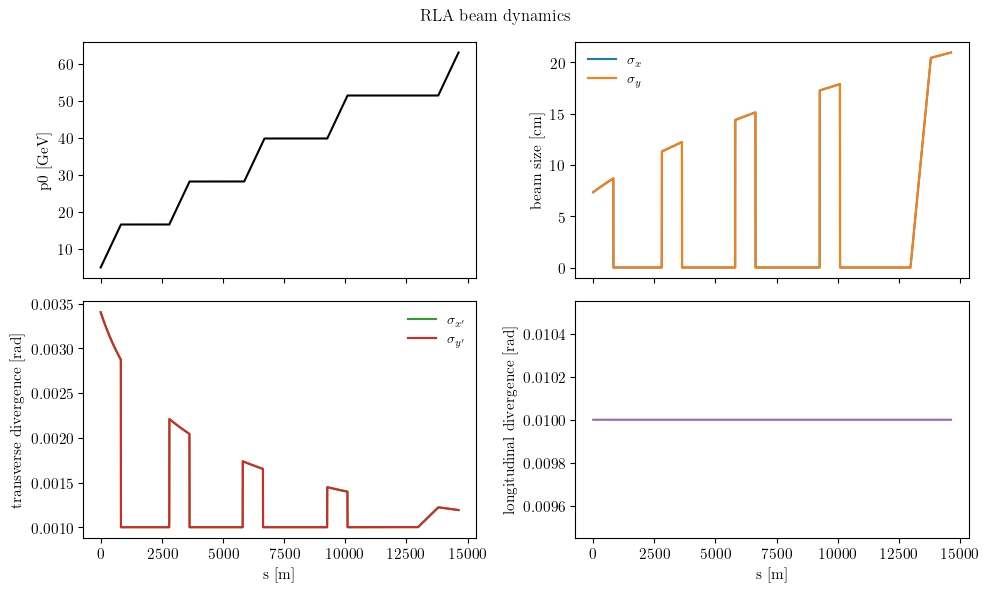

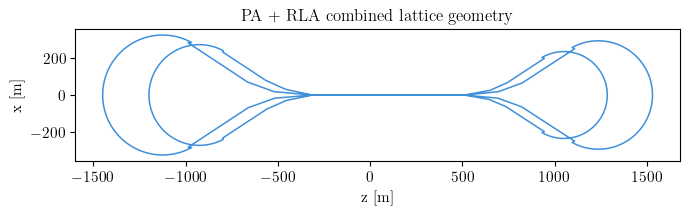

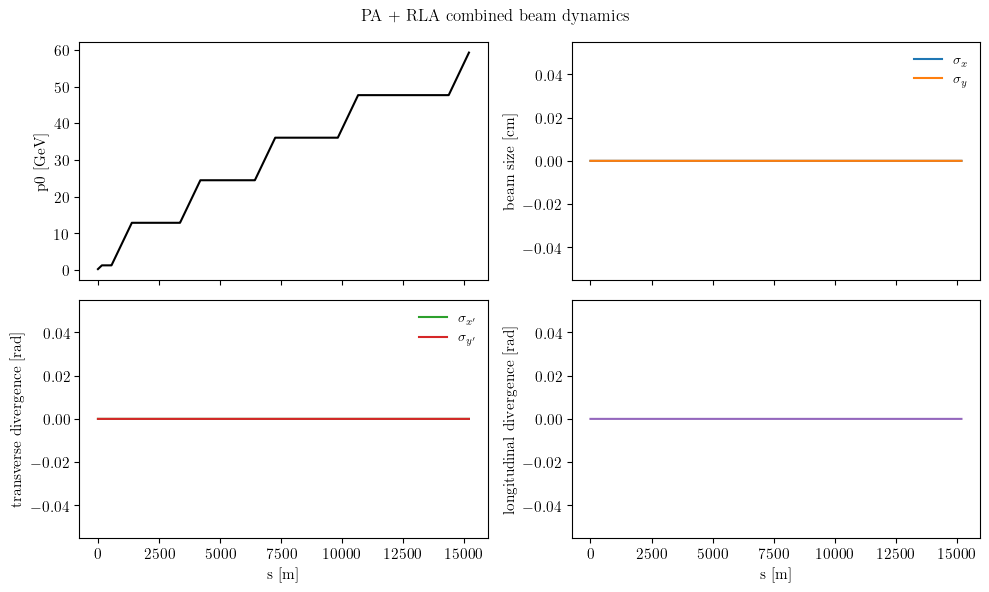

In [12]:
plot_lattice_geometry(pa_lattice, "PA lattice geometry")
plot_beam_dynamics(pa_lattice, "PA beam dynamics")

plot_lattice_geometry(rla_lattice2, "RLA lattice geometry")
plot_beam_dynamics(rla_lattice2, "RLA beam dynamics")

plot_lattice_geometry(combined_lattice, "PA + RLA combined lattice geometry")
plot_beam_dynamics(combined_lattice, "PA + RLA combined beam dynamics")

## Decay simulation and placement on lattices

In [13]:
n_evals = 1e5

simulators = {
    "PA": {
        "lattice": pa_lattice,
        "numu": MuDecaySimulator(muon_polarization=0.0, nuflavor="numu", direction="right", n_evals=n_evals),
        "nue": MuDecaySimulator(muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals),
    },
    "RLA1": {
        "lattice": rla_lattice1,
        "numu": MuDecaySimulator(muon_polarization=0.0, nuflavor="numu", direction="right", n_evals=n_evals),
        "nue": MuDecaySimulator(muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals),
    },
    "RLA2": {
        "lattice": rla_lattice2,
        "numu": MuDecaySimulator(muon_polarization=0.0, nuflavor="numu", direction="right", n_evals=n_evals),
        "nue": MuDecaySimulator(muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals),
    },
    "PA+RLA2": {
        "lattice": combined_lattice,
        "numu": MuDecaySimulator(muon_polarization=0.0, nuflavor="numu", direction="right", n_evals=n_evals),
        "nue": MuDecaySimulator(muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals),
    },
}

for machine_name, cfg in simulators.items():
    for flavor in ["numu", "nue"]:
        sim = cfg[flavor]
        sim.decay_muons()
        sim.place_muons_on_lattice(lattice=cfg["lattice"], direction="clockwise")
    print(f"Finished simulation setup for {machine_name}.")

Finished simulation setup for PA.
Finished simulation setup for RLA1.
Finished simulation setup for RLA2.
Finished simulation setup for PA+RLA2.


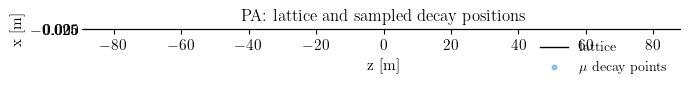

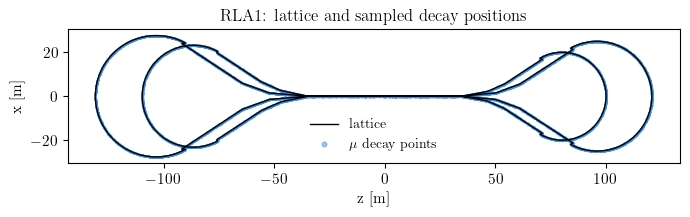

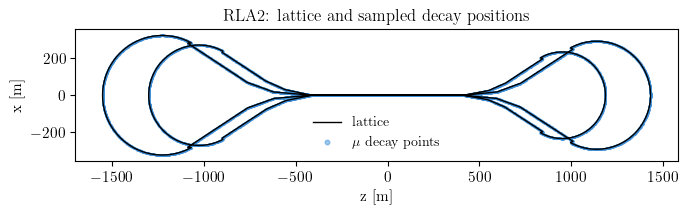

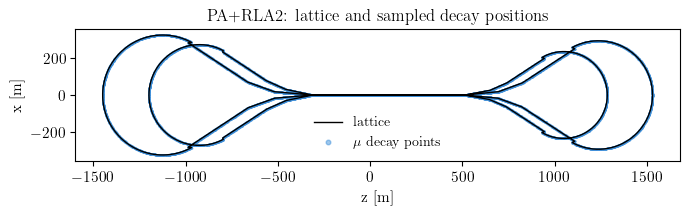

In [14]:
# Quick geometry check with decay positions for one flavor
for machine_name, cfg in simulators.items():
    lattice = cfg["lattice"]
    sim_numu = cfg["numu"]

    plt.figure(figsize=(7, 3))
    plt.plot(lattice.vertices[0] / 100, lattice.vertices[1] / 100, c="black", lw=1.0, label="lattice")

    nshow = min(20000, sim_numu.sample_size)
    idx = np.random.choice(sim_numu.sample_size, size=nshow, replace=False)
    plt.scatter(sim_numu.pos["z"][idx] / 100, sim_numu.pos["x"][idx] / 100, s=0.3, alpha=0.5, label="$\mu$ decay points")

    plt.xlabel("z [m]")
    plt.ylabel("x [m]")
    plt.title(f"{machine_name}: lattice and sampled decay positions")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend(frameon=False, markerscale=6)
    plt.tight_layout()

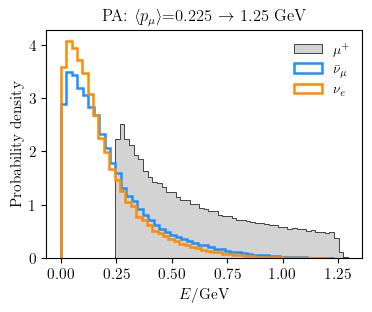

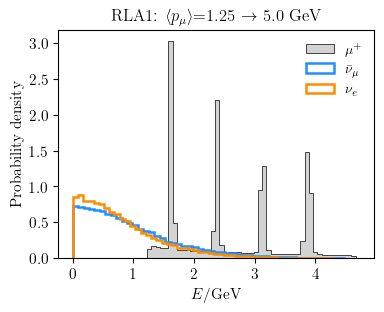

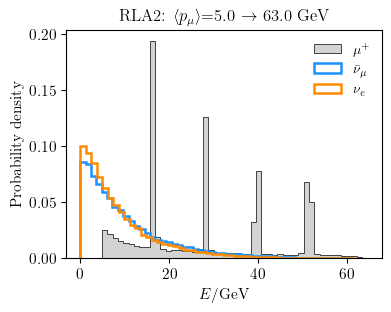

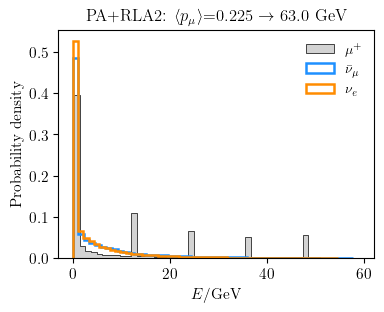

In [15]:
start_end_p = {
    "PA": (0.225, 1.25),
    "RLA1": (1.25, 5.0),
    "RLA2": (5.0, 63.0),
    "PA+RLA2": (0.225, 63.0)}

for machine_name, cfg in simulators.items():
    lattice = cfg["lattice"]
    sim_numu = cfg["numu"]
    sim_nue = cfg["nue"]

    fig, ax = pt.std_fig(figsize=(4,3))
    fsize=12
    n_bins = 50
    ax.hist(sim_numu.pmu['E'], weights=sim_numu.weights[:,0], bins=n_bins, label=r'$\mu^+$', facecolor='lightgrey', edgecolor='black', lw=0.5, histtype='stepfilled', density=True)
    ax.hist(sim_numu.pnu['E'], weights=sim_numu.weights[:,0], lw=1.8, bins=n_bins, label=r'$\bar\nu_\mu$', color='dodgerblue', histtype='step', density=True)
    ax.hist(sim_nue.pnu['E'], weights=sim_nue.weights[:,0], lw=1.8, bins=n_bins, label=r'$\nu_e$', color='darkorange', histtype='step', density=True)

    ax.legend(frameon=False,loc='upper right')
    # ax.set_xlim(0,1.3)
    # ax.set_yscale('log')
    ax.set_ylabel(r'Probability density')
    ax.set_xlabel(r'$E/$GeV')
    plt.title(f"{machine_name}: lattice and sampled decay positions")
    ax.set_title(f"{machine_name}: $\langle p_\mu \\rangle$={start_end_p[machine_name][0]} $\\to$ {start_end_p[machine_name][1]} GeV")

    fig.savefig(f"plots/{machine_name}_energy_spectrum.pdf", dpi=300, bbox_inches='tight')
    

## Flux at different detector locations

TypeError: MuDecaySimulator.get_flux_at_generic_location() got an unexpected keyword argument 'E_cut'

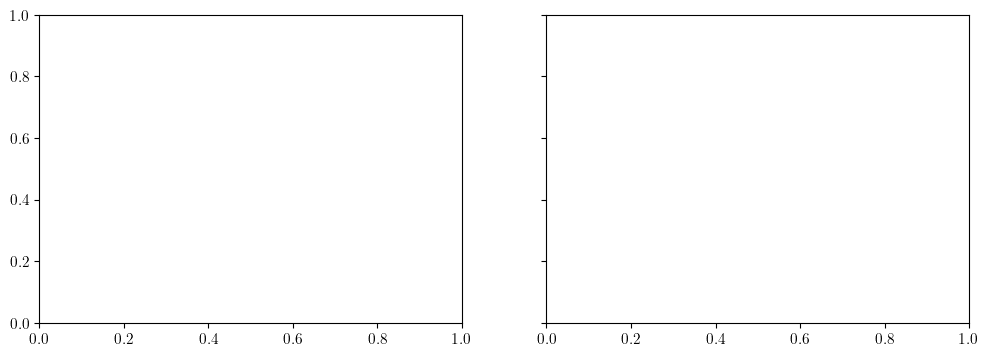

In [9]:
detector_locations = {
    "Near, on-axis": np.array([0.0, 0.0, 300e2]),
    "Mid, on-axis": np.array([0.0, 0.0, 1000e2]),
    "Far, off-axis": np.array([100e2, 0.0, 2000e2]),
}

ebins = np.linspace(0, 40, 121)
det_radius = 5e2

def plot_flux_grid(machine_key):
    cfg = simulators[machine_key]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, flavor in zip(axes, ["numu", "nue"]):
        sim = cfg[flavor]

        for label, loc in detector_locations.items():
            e_edges, flux = sim.get_flux_at_generic_location(
                det_location=loc,
                det_radius=det_radius,
                ebins=ebins,
                E_cut=0,
                acceptance=False,
                per_area=True,
                normalization=1,
            )

            if np.isscalar(e_edges):
                continue

            e_centers = 0.5 * (e_edges[1:] + e_edges[:-1])
            ax.plot(e_centers, flux, lw=1.5, label=label)

        ax.set_yscale("log")
        ax.set_xlabel(r"$E_\nu$ [GeV]")
        ax.set_title(f"{machine_key} - {flavor}")

    axes[0].set_ylabel(r"Flux [cm$^{-2}$ GeV$^{-1}$ per decay]")
    axes[1].legend(frameon=False)
    fig.tight_layout()


for machine in ["PA", "RLA1", "RLA2", "PA+RLA2"]:
    plot_flux_grid(machine)